# CKA Analysis for PAPNet and PCT

## Setup environment and download datasets

In [1]:
REPO_PATH = "/content/pointcloud-bench"

In [2]:
!git clone --recursive --branch final-cka-analysis https://github.com/DavidClaszen/pointcloud-bench {REPO_PATH}

Cloning into '/content/pointcloud-bench'...
remote: Enumerating objects: 519, done.
remote: Counting objects: 100% (42/42), done.
remote: Compressing objects: 100% (37/37), done.
remote: Total 519 (delta 10), reused 13 (delta 5), pack-reused 477 (from 2)
Receiving objects: 100% (519/519), 42.66 MiB | 11.31 MiB/s, done.
Resolving deltas: 100% (225/225), done.
Submodule 'repos/PAPNet' (https://github.com/DavidClaszen/PAPNet.git) registered for path 'repos/PAPNet'
Submodule 'repos/Point-Transformers' (https://github.com/DavidClaszen/Point-Transformers.git) registered for path 'repos/Point-Transformers'
Cloning into '/content/pointcloud-bench/repos/PAPNet'...
remote: Enumerating objects: 144, done.        
remote: Counting objects: 100% (144/144), done.        
remote: Compressing objects: 100% (116/116), done.        
remote: Total 144 (delta 63), reused 88 (delta 27), pack-reused 0 (from 0)        
Receiving objects: 100% (144/144), 9.66 MiB | 7.75 MiB/s, done.
Resolving deltas: 100% (63

In [3]:
# For rolling changes, execute checkout to a select branch
%cd {REPO_PATH}
!git checkout final-cka-analysis
!git fetch origin
!git pull
!git submodule update --init --recursive

/content/pointcloud-bench
Already on 'final-cka-analysis'
Your branch is up to date with 'origin/final-cka-analysis'.
Already up to date.


In [4]:
# Mount drive for pulling data and models
import os
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [5]:
# Define the path to the dataset in Google Drive where the data and models are saved
# The folder must contain the file(s):
# - partialmodelnet40.tar.gz
datasets_folder_path = '/content/drive/MyDrive/_Temp/cs7643-final-proj/pointcloud-bench/datasets'

# The checkpoints path must contain the *.pth files of the trained models
checkpoints_folder_path = '/content/drive/MyDrive/_Temp/cs7643-final-proj/pointcloud-bench/checkpoints'

# This directory is used to save the outputs of this notebook
output_path = '/content/drive/MyDrive/_Temp/cs7643-final-proj/pointcloud-bench/results'

# Check contents to make sure it's there
file_exists = lambda path: os.path.exists(path)
folder_exists = lambda path: os.path.isdir(path)
print("partialmodelnet40: ", "OK" if file_exists(os.path.join(datasets_folder_path, 'partialmodelnet40.tar.gz')) else "NOT FOUND")
print("Trained Models: ", "OK" if folder_exists(os.path.join(checkpoints_folder_path)) else "NOT FOUND")

partialmodelnet40:  OK
Trained Models:  OK


In [6]:
%cd {REPO_PATH}
%pip install -r envs/analysis/requirements.txt  --no-deps

/content/pointcloud-bench
  Cloning https://github.com/AMLab-Amsterdam/lie_learn (to revision master) to /tmp/pip-install-k627hj2x/lie-learn_0946e883bc364b8ab77d183c02f2824d
  Running command git clone --filter=blob:none --quiet https://github.com/AMLab-Amsterdam/lie_learn /tmp/pip-install-k627hj2x/lie-learn_0946e883bc364b8ab77d183c02f2824d
  Resolved https://github.com/AMLab-Amsterdam/lie_learn to commit edf012f5f60af320175d2e6269db78b984b5bfc3
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 81.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 736.6/736.6 kB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━

In [7]:
# Copy select file(s) from Google Drive to the repo dataset folder
!rsync -avP {datasets_folder_path}/partialmodelnet40.tar.gz {REPO_PATH}/datasets

sending incremental file list
partialmodelnet40.tar.gz
  2,162,130,396 100%   56.55MB/s    0:00:36 (xfr#1, to-chk=0/1)

sent 2,162,658,366 bytes  received 35 bytes  56,172,945.48 bytes/sec
total size is 2,162,130,396  speedup is 1.00


In [8]:
# Copy the models
!rsync -avP {checkpoints_folder_path}/papnet*.pth {REPO_PATH}/repos/PAPNet/trained_models/
!rsync -avP {checkpoints_folder_path}/pct_*.pth {REPO_PATH}/checkpoints

sending incremental file list
created directory /content/pointcloud-bench/repos/PAPNet/trained_models
papnet-o_full.pth
      5,969,143 100%   19.13MB/s    0:00:00 (xfr#1, to-chk=2/3)
papnet_full.pth
      5,969,143 100%    4.10MB/s    0:00:01 (xfr#2, to-chk=1/3)
papnet_p50.pth
      5,967,791 100%    5.27MB/s    0:00:01 (xfr#3, to-chk=0/3)

sent 17,910,673 bytes  received 149 bytes  3,980,182.67 bytes/sec
total size is 17,906,077  speedup is 1.00
sending incremental file list
pct_p50.pth
     34,642,686 100%   22.67MB/s    0:00:01 (xfr#1, to-chk=6/7)
pct_p50_pct.pth
     34,642,524 100%   12.28MB/s    0:00:02 (xfr#2, to-chk=5/7)
pct_p50_pfull.pth
     34,641,253 100%   11.03MB/s    0:00:02 (xfr#3, to-chk=4/7)
pct_pct.pth
     34,642,219 100%   23.23MB/s    0:00:01 (xfr#4, to-chk=3/7)
pct_pct_p50.pth
     34,641,609 100%   11.16MB/s    0:00:02 (xfr#5, to-chk=2/7)
pct_pfull.pth
     34,642,686 100%   11.66MB/s    0:00:02 (xfr#6, to-chk=1/7)
pct_pfull_p50.pth
     34,642,379 100%   10.45

In [9]:
# Extract compressed files
!tar -xvzf {REPO_PATH}/datasets/partialmodelnet40.tar.gz -C {REPO_PATH}/datasets

partialmodelnet40/
partialmodelnet40/test_labels.npy
partialmodelnet40/test_gt_tra.npy
partialmodelnet40/test_gt_rot.npy
partialmodelnet40/partialmodelnet40_shape_names.txt
partialmodelnet40/partialmodelnet40_test.txt
partialmodelnet40/partialmodelnet40_train.txt
partialmodelnet40/train_points.npy
partialmodelnet40/train_labels.npy
partialmodelnet40/train_gt_tra.npy
partialmodelnet40/train_gt_rot.npy
partialmodelnet40/test_points.npy


# CKA Calculations

In [10]:
import sys
import gc
import numpy as np
import torch
import torch.nn as nn

from torch.utils.data import DataLoader
from tqdm import tqdm
from typing import List

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

sys.path.append(f"{REPO_PATH}/notebooks/")
sys.path.append(f"{REPO_PATH}/repos/PAPNet/")
sys.path.append(f"{REPO_PATH}/repos/Point-Transformers/")

from CKA import CKA, CudaCKA
from eval_models import eval_papnet
from dataloader import DataLoader as PAPNetDataset
from model import Model as PAPNetModel

def compute_cka_matrix(features):
  # Compute CKA similarity matrix between all layers
  n_layers = len(features)
  cka_matrix = np.zeros((n_layers, n_layers))

  cuda_cka = CudaCKA(device)
  indices = np.triu_indices(len(features))
  print(f"Computing CKA for {n_layers} layers...")
  for ix in tqdm(range(len(indices[0])), desc="Calculating CKA"):
      i, j = indices[0][ix], indices[1][ix]
      # Convert to torch tensors and move to device
      X_i = torch.from_numpy(features[i]).to(device)
      X_j = torch.from_numpy(features[j]).to(device)

      # Compute linear CKA
      cka_score = cuda_cka.linear_CKA(X_i, X_j)
      cka_matrix[i, j] = cka_score
      cka_matrix[j, i] = cka_score  # Symmetric

      # Clean cache
      del X_i, X_j
      torch.cuda.empty_cache()
  return cka_matrix

def compute_cka_cross(features1: list, features2: list, device: torch.device) -> np.array:
    """
    Compute CKA similarity between two sets of features.

    Args:
        features1: list of np.ndarray, features from model 1
        features2: list of np.ndarray, features from model 2
        device: torch.device to run the computation on

    Returns:
        cka_scores: np.ndarray of shape (len(features1), len(features2)) with CKA similarity scores
    """
    cuda_cka = CudaCKA(device)

    cka_score = np.zeros((len(features1), len(features2)))
    print(f"Computing cross CKA for {len(features1)} x {len(features2)} layers...")

    row_idx, col_idx = np.indices((len(features1), len(features2)))

    for i, j in tqdm(zip(row_idx.flatten(), col_idx.flatten()), total=len(features1)*len(features2), desc="Cross CKA"):
        # Convert to torch tensors and move to device
        X_i = torch.from_numpy(features1[i]).to(device)
        X_j = torch.from_numpy(features2[j]).to(device)

        # Compute linear CKA
        cka_score[i, j] = cuda_cka.linear_CKA(X_i, X_j)

        # Clean cache
        del X_i, X_j
        torch.cuda.empty_cache()

    return cka_score

def print_samples_and_memory(features):
  print("Total number of activation samples:", features[0].shape[0])
  print("Number of activation samples per layer:")
  total_size_bytes = 0.0
  for i, feat in enumerate(features):
      size_bytes = feat.shape[0] * feat.shape[1] * feat.dtype.itemsize
      total_size_bytes += size_bytes
      print(f"Layer {i+1}: {feat.shape[0]} samples, {feat.shape[1]} features, total of {(size_bytes /  (1024**2)):.6f} MB")
  print(f"Total size of all activations: {(total_size_bytes /  (1024**2)):.2f} MB")

def viz_cka_matrix(cka_matrix, tick_interval=5, xylabel='Layers', title=''):
    fig, ax = plt.subplots(figsize=(6, 5), dpi=150)
    ax = sns.heatmap(cka_matrix,
                cmap='magma', annot=False, ax=ax, vmin=0.0, vmax=1.0, cbar=False)
    ax.set_title(title, fontsize=20)
    ax.set_xlabel(xylabel, fontsize=18)
    ax.set_ylabel(xylabel, fontsize=18)
    ax.invert_yaxis()  # So that first layer is at the bottom
    return fig, ax

/content/pointcloud-bench/repos/PAPNet/lib/transformations.py:67: SyntaxWarning: invalid escape sequence '\*'
  numpy.dot(M, v) for shape (4, \*) column vectors, respectively
/content/pointcloud-bench/repos/PAPNet/lib/transformations.py:893: SyntaxWarning: invalid escape sequence '\*'
  v0 and v1 are shape (ndims, \*) arrays of at least ndims non-homogeneous
/content/pointcloud-bench/repos/PAPNet/lib/transformations.py:1002: SyntaxWarning: invalid escape sequence '\*'
  v0 and v1 are shape (3, \*) or (4, \*) arrays of at least 3 points.


We make our own sampler to ensure that the same data is used in the calculation of PAPNet and PCT.

In [11]:
class SequenceSampler(torch.utils.data.Sampler):
    """Sampler that yields a fixed, user-provided sequence of indices."""
    def __init__(self, indices):
        """
        Args:
            indices: sequence of indices (list, tuple, np.array, torch.Tensor)
        """
        # Convert to a simple list of ints
        self.indices = list(map(int, indices))

    def __iter__(self):
        # DataLoader will call this each epoch; we just replay the sequence
        for idx in self.indices:
            yield idx

    def __len__(self):
        # Number of samples the sampler will produce
        return len(self.indices)

In [12]:
######################################
# Set these numbers to desired items
NUM_EPOCH = 32
NUM_BATCHES = 10
######################################

In [13]:
# create directory for results
if os.path.exists(os.path.join(output_path, "cka")) == False:
  os.mkdir(os.path.join(output_path, "cka"))

## 1. Intra CKA for PAPNet

In [14]:
%cd {REPO_PATH}

/content/pointcloud-bench


In [15]:
def get_layer_repr_papnet(model: nn.Module,
                          layers: List[nn.Module],
                          dataloader: DataLoader,
                          device: torch.device,
                          max_batches: int = None):
    """
    Extract activations from specific layers for all data in dataloader.

    Args:
        model: PyTorch model
        layers: list of nn.Module, the layer(s) from which to extract features
        dataloader: DataLoader providing the data
        device: torch.device to run the model on
        max_batches: Optional[int], maximum number of batches to process

    Returns:
        features: np.ndarray of shape (N, D) where N is number of samples and D is feature dimension
        labels: np.ndarray of shape (N,) corresponding labels
    """
    model.eval()
    model.to(device)

    captured = {}
    handles = []

    def hook_fn(module, inp, out):
        # out: (B, D, ...) depending on layer
        captured[id(module)] = out.detach()

    for layer in layers:
        handles.append(layer.register_forward_hook(hook_fn))

    feats_list = [[] for _ in layers]
    labels_list = []

    with torch.no_grad():
        for b_idx, batch in enumerate(tqdm(dataloader, desc="Extracting features")):
            vol, gt_cls, gt_rot, gt_noi = batch
            vol = vol.to(device)

            _ = model(vol)               # forward; hook will populate captured[id(module)]

            # flatten the captured features
            for i, layer in enumerate(layers):
                feat = captured[id(layer)]  # (B, D, ...)
                feat = torch.flatten(feat, start_dim=1)  # (B, D)
                feats_list[i].append(feat.cpu())

            labels_list.append(gt_cls.cpu())

            if max_batches is not None and (b_idx + 1) >= max_batches:
                tqdm.write(f"Reached max_batches={max_batches}, stopping feature extraction.")
                break

    # Remove hooks
    for h in handles:
        h.remove()

    features = [torch.cat(feats, dim=0).numpy() for feats in feats_list]  # List of (N, D) arrays
    labels = torch.cat(labels_list, dim=0).numpy()   # (N,)
    return features, labels

def get_forward_order_papnet(model, dataset, device):
    """
    Get the order of module execution during a forward pass.

    Args:
        model: PyTorch model
        dataset: Dataset providing the data
        device: torch.device to run the model on
    Returns:
        tuple
          - layers:       list of modules in the order they were executed.
          - layer_names:  names of the modules
    """
    layers = []
    layer_names = []
    module_to_name = dict()

    # Get one sample to be used for determining the execution order
    sample_input = next(iter(torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=False)))

    def hook_fn(module, input, output):
        layers.append(module)
        layer_names.append(module_to_name[module])

    hooks = []
    for name, module in model.named_children():
      if isinstance(module, (nn.BatchNorm1d, nn.LayerNorm)):
        # Skip BatchNorm1d
        continue
      hooks.append(module.register_forward_hook(hook_fn))
      module_to_name[module] = "self." + name

    # Run a forward pass
    with torch.no_grad():
        vol, gt_cls, gt_rot, gt_noi = sample_input
        vol = vol.to(device)
        _ = model(vol)

    # Clean up hooks
    for h in hooks:
        h.remove()

    return layers, layer_names


### Data loading

In [16]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

# Load data
test_dataset_papnet = PAPNetDataset("pm40", root=f"{REPO_PATH}/datasets/partialmodelnet40", split='test')

# Prepare a sampler that will be used for all models
np.random.seed(6969)
datasampler = SequenceSampler(np.random.randint(0, len(test_dataset_papnet), size=NUM_EPOCH * NUM_BATCHES))

test_dataloader_papnet = torch.utils.data.DataLoader(test_dataset_papnet, batch_size=32, shuffle=False, sampler=datasampler, pin_memory=True)

The size of test data is 2468


In [17]:
for b_idx, batch in enumerate(test_dataloader_papnet):
  _, gt_cls, _, _ = batch
  print(gt_cls[:].tolist())

[8, 15, 17, 38, 21, 27, 22, 0, 22, 8, 7, 36, 26, 12, 2, 34, 14, 8, 5, 17, 21, 20, 21, 16, 17, 0, 22, 16, 36, 2, 16, 39]
[8, 36, 0, 17, 1, 36, 4, 34, 33, 16, 36, 26, 20, 25, 8, 28, 35, 4, 18, 33, 4, 8, 1, 35, 17, 35, 28, 28, 28, 37, 7, 26]
[25, 7, 21, 13, 29, 35, 21, 35, 14, 29, 30, 5, 8, 22, 18, 33, 30, 26, 7, 5, 12, 21, 8, 12, 33, 35, 12, 24, 17, 35, 12, 22]
[20, 16, 25, 22, 0, 28, 20, 2, 19, 28, 21, 26, 8, 26, 33, 33, 19, 0, 25, 19, 8, 26, 7, 14, 2, 35, 37, 22, 30, 13, 12, 25]
[5, 23, 37, 0, 26, 18, 7, 7, 35, 18, 16, 0, 1, 38, 16, 25, 35, 8, 5, 8, 5, 14, 22, 22, 8, 14, 6, 1, 28, 17, 16, 31]
[12, 35, 33, 4, 30, 36, 35, 0, 23, 33, 4, 16, 32, 5, 8, 33, 14, 17, 5, 0, 23, 36, 12, 35, 4, 36, 4, 26, 28, 7, 26, 27]
[21, 13, 28, 33, 17, 0, 26, 5, 12, 3, 36, 5, 14, 37, 27, 2, 28, 21, 22, 11, 33, 1, 28, 30, 8, 30, 37, 23, 22, 1, 21, 22]
[8, 34, 7, 2, 5, 28, 37, 25, 27, 30, 28, 22, 37, 33, 36, 4, 12, 33, 14, 8, 35, 37, 30, 15, 36, 30, 7, 5, 28, 4, 20, 36]
[37, 30, 17, 21, 14, 9, 37, 33, 25, 7, 3

### Layer Information

In [18]:
model_with_dataparallel = nn.DataParallel(PAPNetModel(num_class=40, num_k=1))
model_with_dataparallel.load_state_dict(torch.load(f"{REPO_PATH}/repos/PAPNet/trained_models/papnet_p50.pth"), strict=False)
model_papnet = model_with_dataparallel.module.cuda()

model_papnet.eval()

layers_ord_papnet, layers_names_papnet = get_forward_order_papnet(model_papnet, test_dataset_papnet, device)
print(f"Model has {len(layers_ord_papnet)} 1st-order network layer")

compute 0.pkl.gz... save 0.pkl.gz... done
compute 0.pkl.gz... save 0.pkl.gz... done
compute 1.pkl.gz... save 1.pkl.gz... done
compute 1.pkl.gz... save 1.pkl.gz... done
compute 2.pkl.gz... save 2.pkl.gz... done
compute 2.pkl.gz... save 2.pkl.gz... done
compute 3.pkl.gz... save 3.pkl.gz... done
compute 3.pkl.gz... save 3.pkl.gz... done
compute 4.pkl.gz... save 4.pkl.gz... done
compute 5.pkl.gz... save 5.pkl.gz... done
compute 6.pkl.gz... save 6.pkl.gz... done
compute 7.pkl.gz... save 7.pkl.gz... done
compute 8.pkl.gz... save 8.pkl.gz... done
compute 9.pkl.gz... save 9.pkl.gz... done
compute 10.pkl.gz... save 10.pkl.gz... done
compute 11.pkl.gz... save 11.pkl.gz... done
compute 12.pkl.gz... save 12.pkl.gz... done
compute 13.pkl.gz... save 13.pkl.gz... done
compute 14.pkl.gz... save 14.pkl.gz... done
compute 4.pkl.gz... save 4.pkl.gz... done
compute 15.pkl.gz... save 15.pkl.gz... done
compute 16.pkl.gz... save 16.pkl.gz... done
compute 17.pkl.gz... save 17.pkl.gz... done
compute 18.pkl.gz.

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:85: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/functional.py:5167: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  warnings.warn(
/usr/local/lib/python3.12/dist-pac

Model has 33 1st-order network layer


In [19]:
for i, layer in enumerate(layers_ord_papnet):
  print(f"Layer {i+1}: {layer.__class__.__name__} ({layers_names_papnet[i]})")

Layer 1: GatedBlock (self.conv1)
Layer 2: AvgPool3d (self.avgpool)
Layer 3: GatedBlock (self.conv21)
Layer 4: GatedBlock (self.conv22)
Layer 5: AvgPool3d (self.avgpool)
Layer 6: GatedBlock (self.conv23)
Layer 7: GatedBlock (self.conv24)
Layer 8: GatedBlock (self.conv31)
Layer 9: GatedBlock (self.conv32)
Layer 10: AvgPool3d (self.avgpool)
Layer 11: GatedBlock (self.conv41)
Layer 12: GatedBlock (self.conv42)
Layer 13: Upsample (self.up)
Layer 14: GatedBlock (self.convp1)
Layer 15: AvgPool3d (self.avgpool)
Layer 16: GatedBlock (self.conv51)
Layer 17: GatedBlock (self.conv52)
Layer 18: AvgSpacial (self.gblpool)
Layer 19: Linear (self.fc1)
Layer 20: ReLU (self.relu)
Layer 21: Linear (self.fc2)
Layer 22: ReLU (self.relu)
Layer 23: Linear (self.fc3)
Layer 24: GatedBlock (self.conv0_c)
Layer 25: AvgPool3d (self.avgpool)
Layer 26: GatedBlock (self.conv1_c)
Layer 27: GatedBlock (self.conv2_c)
Layer 28: AvgSpacial (self.gblpool)
Layer 29: Linear (self.fc1_c)
Layer 30: ReLU (self.relu)
Layer 31: L

In [20]:
features_papnet, labels_papnet = get_layer_repr_papnet(
    model=model_papnet,
    layers=layers_ord_papnet,
    dataloader=test_dataloader_papnet,
    device=device,
    max_batches=10  # limit to 10 batches for speed
)

Extracting features:  90%|█████████ | 9/10 [00:19<00:02,  2.13s/it]


Reached max_batches=10, stopping feature extraction.


In [21]:
print_samples_and_memory(features_papnet)

Total number of activation samples: 320
Number of activation samples per layer:
Layer 1: 320 samples, 8388608 features, total of 10240.000000 MB
Layer 2: 320 samples, 131072 features, total of 160.000000 MB
Layer 3: 320 samples, 2097152 features, total of 2560.000000 MB
Layer 4: 320 samples, 2097152 features, total of 2560.000000 MB
Layer 5: 320 samples, 131072 features, total of 160.000000 MB
Layer 6: 320 samples, 262144 features, total of 320.000000 MB
Layer 7: 320 samples, 262144 features, total of 320.000000 MB
Layer 8: 320 samples, 524288 features, total of 640.000000 MB
Layer 9: 320 samples, 524288 features, total of 640.000000 MB
Layer 10: 320 samples, 131072 features, total of 160.000000 MB
Layer 11: 320 samples, 131072 features, total of 160.000000 MB
Layer 12: 320 samples, 131072 features, total of 160.000000 MB
Layer 13: 320 samples, 1048576 features, total of 1280.000000 MB
Layer 14: 320 samples, 1048576 features, total of 1280.000000 MB
Layer 15: 320 samples, 131072 featur

In [22]:
cka_matrix_papnet = compute_cka_matrix(features_papnet)
print("CKA similarity calculation complete.")

Computing CKA for 33 layers...


Calculating CKA: 100%|██████████| 561/561 [04:13<00:00,  2.22it/s]

CKA similarity calculation complete.


In [23]:
np.save(os.path.join(output_path, "cka", "cka_matrix_papnet.npy"), cka_matrix_papnet)
np.savetxt(os.path.join(output_path, "cka", "cka_matrix_papnet.csv"), cka_matrix_papnet, delimiter=",")

### Intra-layer CKA

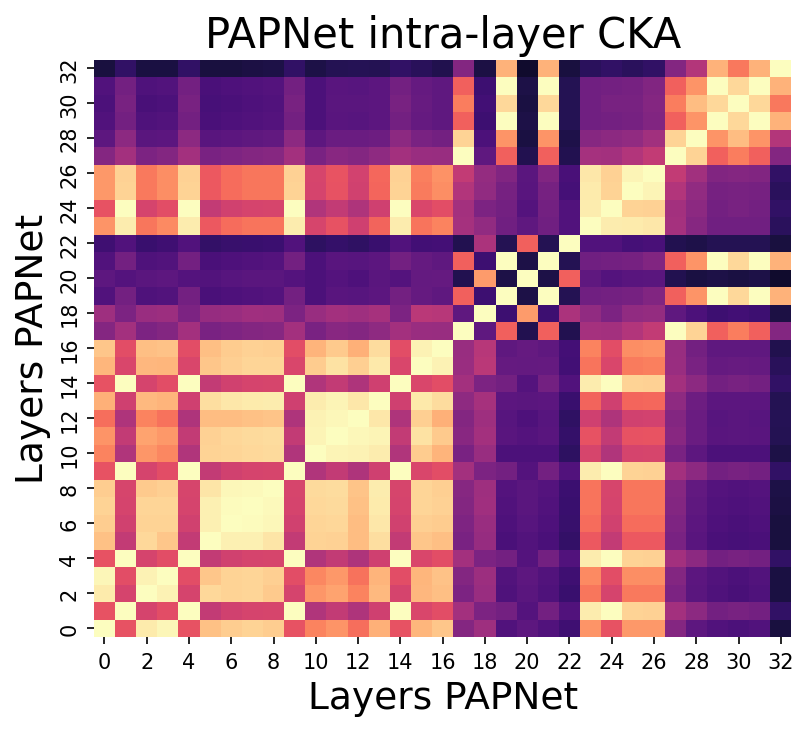

In [24]:
# Now visualize the CKA matrix using seaborn heatmap
fig, ax = viz_cka_matrix(cka_matrix=cka_matrix_papnet,
                         tick_interval=5,
                         xylabel='Layers PAPNet', title='PAPNet intra-layer CKA')
# save graph
fig.savefig(os.path.join(output_path, "cka", "cka_papnet.svg"), bbox_inches='tight')

## 2. Intra CKA for PCT

In [25]:
import os
import hydra
import importlib
from hydra import initialize_config_dir, compose
from test_cls import get_predictions
from omegaconf import OmegaConf
from dataset import PAPNetDataLoader as PCTDataset

# Train PCT, test PAPNet
torch.serialization.add_safe_globals([
    np.core.multiarray.scalar,  # For NumPy scalars
    np.dtype,                   # For NumPy data types
    np.dtype('float64').__class__, # For the specific float64 dtype class
])

config_dir = os.path.join(REPO_PATH, 'repos', 'Point-Transformers', 'config')

with initialize_config_dir(config_dir=config_dir, version_base="1.2"):
    cfg = compose(
        config_name="cls",
        overrides=[
            f"data_path={REPO_PATH}/datasets/partialmodelnet40/",
            f"checkpoint_path={checkpoints_folder_path}/pct_p50.pth",
            "use_papnet_loader=true"
        ],
    )

OmegaConf.set_struct(cfg, False)

In [26]:
%cd {REPO_PATH}/repos/Point-Transformers

/content/pointcloud-bench/repos/Point-Transformers


### Data loading

In [27]:
# Load data
args = cfg
test_dataset_pct = PCTDataset(
    root=hydra.utils.to_absolute_path(args.data_path),
    npoint=args.num_point,
    split='test',
    normal_channel=args.normal,
)

test_loader_pct = torch.utils.data.DataLoader(
    test_dataset_pct,
    batch_size=32,
    shuffle=False,
    sampler=datasampler,
    pin_memory=True,
    num_workers=args.workers,
)

# ---- MODEL LOADING ----
args.num_class = 40
args.input_dim = 6 if args.normal else 3
ModelCls = getattr(
    importlib.import_module(f"models.{args.model.name}.model"),
    "PointTransformerCls",
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_pct = ModelCls(args).to(device)
checkpoint = torch.load(args.checkpoint_path, map_location=device)
model_pct.load_state_dict(checkpoint["model_state_dict"])
print(f"Model loaded with {checkpoint['epoch']} epochs")
model_pct.eval()

The size of test data is 2468
Model loaded with 42 epochs


PointTransformerCls(
  (conv1): Conv1d(6, 64, kernel_size=(1,), stride=(1,), bias=False)
  (conv2): Conv1d(64, 64, kernel_size=(1,), stride=(1,), bias=False)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (gather_local_0): Local_op(
    (conv1): Conv1d(128, 128, kernel_size=(1,), stride=(1,), bias=False)
    (conv2): Conv1d(128, 128, kernel_size=(1,), stride=(1,), bias=False)
    (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
  )
  (gather_local_1): Local_op(
    (conv1): Conv1d(256, 256, kernel_size=(1,), stride=(1,), bias=False)
    (conv2): Conv1d(256, 256, kernel_size=(1,), stride=(1,), bias=False)
    (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (bn2): Ba

In [28]:
for b_idx, batch in enumerate(test_loader_pct):
  points, target = batch
  print(target[:].flatten().tolist())

[8, 15, 17, 38, 21, 27, 22, 0, 22, 8, 7, 36, 26, 12, 2, 34, 14, 8, 5, 17, 21, 20, 21, 16, 17, 0, 22, 16, 36, 2, 16, 39]
[8, 36, 0, 17, 1, 36, 4, 34, 33, 16, 36, 26, 20, 25, 8, 28, 35, 4, 18, 33, 4, 8, 1, 35, 17, 35, 28, 28, 28, 37, 7, 26]
[25, 7, 21, 13, 29, 35, 21, 35, 14, 29, 30, 5, 8, 22, 18, 33, 30, 26, 7, 5, 12, 21, 8, 12, 33, 35, 12, 24, 17, 35, 12, 22]
[20, 16, 25, 22, 0, 28, 20, 2, 19, 28, 21, 26, 8, 26, 33, 33, 19, 0, 25, 19, 8, 26, 7, 14, 2, 35, 37, 22, 30, 13, 12, 25]
[5, 23, 37, 0, 26, 18, 7, 7, 35, 18, 16, 0, 1, 38, 16, 25, 35, 8, 5, 8, 5, 14, 22, 22, 8, 14, 6, 1, 28, 17, 16, 31]
[12, 35, 33, 4, 30, 36, 35, 0, 23, 33, 4, 16, 32, 5, 8, 33, 14, 17, 5, 0, 23, 36, 12, 35, 4, 36, 4, 26, 28, 7, 26, 27]
[21, 13, 28, 33, 17, 0, 26, 5, 12, 3, 36, 5, 14, 37, 27, 2, 28, 21, 22, 11, 33, 1, 28, 30, 8, 30, 37, 23, 22, 1, 21, 22]
[8, 34, 7, 2, 5, 28, 37, 25, 27, 30, 28, 22, 37, 33, 36, 4, 12, 33, 14, 8, 35, 37, 30, 15, 36, 30, 7, 5, 28, 4, 20, 36]
[37, 30, 17, 21, 14, 9, 37, 33, 25, 7, 3

In [52]:
from models.Menghao.model import Local_op, StackedAttention

def get_layer_repr_pct(model: nn.Module,
                       layers: List[nn.Module],
                       dataloader: DataLoader,
                       device: torch.device,
                       max_batches: int = None):
    """
    Extract activations from specific layers for all data in dataloader.

    Args:
        model: PyTorch model
        layers: list of nn.Module, the layer(s) from which to extract features
        dataloader: DataLoader providing the data
        device: torch.device to run the model on
        max_batches: Optional[int], maximum number of batches to process

    Returns:
        features: np.ndarray of shape (N, D) where N is number of samples and D is feature dimension
        labels: np.ndarray of shape (N,) corresponding labels
    """
    model.eval()
    model.to(device)

    captured = {}
    handles = []

    def hook_fn(module, inp, out):
        # out: (B, D, ...) depending on layer
        captured[id(module)] = out.detach()

    for layer in layers:
        handles.append(layer.register_forward_hook(hook_fn))

    feats_list = [[] for _ in layers]
    labels_list = []

    with torch.no_grad():
        for b_idx, batch in enumerate(tqdm(dataloader, desc="Extracting features")):
            points, target = batch
            target = target[:, 0]
            points = points.to(device)
            _ = model(points)               # forward; hook will populate captured[id(module)]

            # flatten the captured features
            for i, layer in enumerate(layers):
                feat = captured[id(layer)]  # (B, D, ...)
                feat = torch.flatten(feat, start_dim=1)  # (B, D)
                feats_list[i].append(feat.cpu())

            labels_list.append(target.cpu())

            if max_batches is not None and (b_idx + 1) >= max_batches:
                tqdm.write(f"Reached max_batches={max_batches}, stopping feature extraction.")
                break

    # Remove hooks
    for h in handles:
        h.remove()

    features = [torch.cat(feats, dim=0).numpy() for feats in feats_list]  # List of (N, D) arrays
    labels = torch.cat(labels_list, dim=0).numpy()   # (N,)
    return features, labels

def get_forward_order_pct(model, dataset, device):
    """
    Get the order of module execution during a forward pass.

    Args:
        model: PyTorch model
        dataset: Dataset providing the data
        device: torch.device to run the model on
    Returns:
          tuple
          - layers:       list of modules in the order they were executed.
          - layer_names:  names of the modules
    """
    layers = []
    layer_names = []
    module_to_name = dict()

    # Get one sample to be used for determining the execution order
    sample_input = next(iter(torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=False)))

    def hook_fn(module, input, output):
        layers.append(module)
        layer_names.append(module_to_name[module])

    hooks = []
    for name, module in model.named_children():
      if isinstance(module, (nn.BatchNorm1d, nn.LayerNorm)):
        # Skip normalizations
        continue
      if isinstance(module, (StackedAttention)):
        # get 2nd level
        for name_child, module_child in module.named_children():
          if isinstance(module_child, (nn.BatchNorm1d, nn.LayerNorm)):
            # Skip normalizations
            continue
          hooks.append(module_child.register_forward_hook(hook_fn))
          module_to_name[module_child] = "self." + name + "." + name_child
      else:
        hooks.append(module.register_forward_hook(hook_fn))
        module_to_name[module] = "self." + name

    # Run a forward pass
    with torch.no_grad():
        points, target = sample_input
        points = points.to(device)
        _ = model(points)

    # Clean up hooks
    for h in hooks:
        h.remove()

    return layers, layer_names

### Layer Information

In [53]:
layers_ord_pct, layer_names_pct = get_forward_order_pct(model_pct, test_dataset_pct, device)
print(f"Model has {len(layers_ord_pct)} 1st-order network layer")

Model has 22 1st-order network layer


In [54]:
for i, layer in enumerate(layers_ord_pct):
  print(f"Layer {i+1}: {layer.__class__.__name__} ({layer_names_pct[i]})")

Layer 1: Conv1d (self.conv1)
Layer 2: ReLU (self.relu)
Layer 3: Conv1d (self.conv2)
Layer 4: ReLU (self.relu)
Layer 5: Local_op (self.gather_local_0)
Layer 6: Local_op (self.gather_local_1)
Layer 7: Conv1d (self.pt_last.conv1)
Layer 8: ReLU (self.pt_last.relu)
Layer 9: Conv1d (self.pt_last.conv2)
Layer 10: ReLU (self.pt_last.relu)
Layer 11: SA_Layer (self.pt_last.sa1)
Layer 12: SA_Layer (self.pt_last.sa2)
Layer 13: SA_Layer (self.pt_last.sa3)
Layer 14: SA_Layer (self.pt_last.sa4)
Layer 15: Sequential (self.conv_fuse)
Layer 16: Linear (self.linear1)
Layer 17: ReLU (self.relu)
Layer 18: Dropout (self.dp1)
Layer 19: Linear (self.linear2)
Layer 20: ReLU (self.relu)
Layer 21: Dropout (self.dp2)
Layer 22: Linear (self.linear3)


In [55]:
features_pct, labels_pct = get_layer_repr_pct(
    model=model_pct,
    layers=layers_ord_pct,
    dataloader=test_loader_pct,
    device=device,
    max_batches=10  # limit to 10 batches for memory
)

Extracting features:  90%|█████████ | 9/10 [00:03<00:00,  3.53it/s]

Reached max_batches=10, stopping feature extraction.


Extracting features:  90%|█████████ | 9/10 [00:03<00:00,  2.43it/s]


In [56]:
print_samples_and_memory(features_pct)

Total number of activation samples: 320
Number of activation samples per layer:
Layer 1: 320 samples, 65536 features, total of 80.000000 MB
Layer 2: 320 samples, 256 features, total of 0.312500 MB
Layer 3: 320 samples, 65536 features, total of 80.000000 MB
Layer 4: 320 samples, 256 features, total of 0.312500 MB
Layer 5: 320 samples, 65536 features, total of 80.000000 MB
Layer 6: 320 samples, 65536 features, total of 80.000000 MB
Layer 7: 320 samples, 65536 features, total of 80.000000 MB
Layer 8: 320 samples, 65536 features, total of 80.000000 MB
Layer 9: 320 samples, 65536 features, total of 80.000000 MB
Layer 10: 320 samples, 65536 features, total of 80.000000 MB
Layer 11: 320 samples, 65536 features, total of 80.000000 MB
Layer 12: 320 samples, 65536 features, total of 80.000000 MB
Layer 13: 320 samples, 65536 features, total of 80.000000 MB
Layer 14: 320 samples, 65536 features, total of 80.000000 MB
Layer 15: 320 samples, 262144 features, total of 320.000000 MB
Layer 16: 320 samp

In [57]:
cka_matrix_pct = compute_cka_matrix(features_pct)

Computing CKA for 22 layers...


Calculating CKA: 100%|██████████| 253/253 [00:08<00:00, 31.25it/s]


In [59]:
np.save(os.path.join(output_path, "cka", "cka_matrix_pct.npy"), cka_matrix_pct)
np.savetxt(os.path.join(output_path, "cka", "cka_matrix_pct.csv"), cka_matrix_pct, delimiter=",")

### Intra-layer CKA

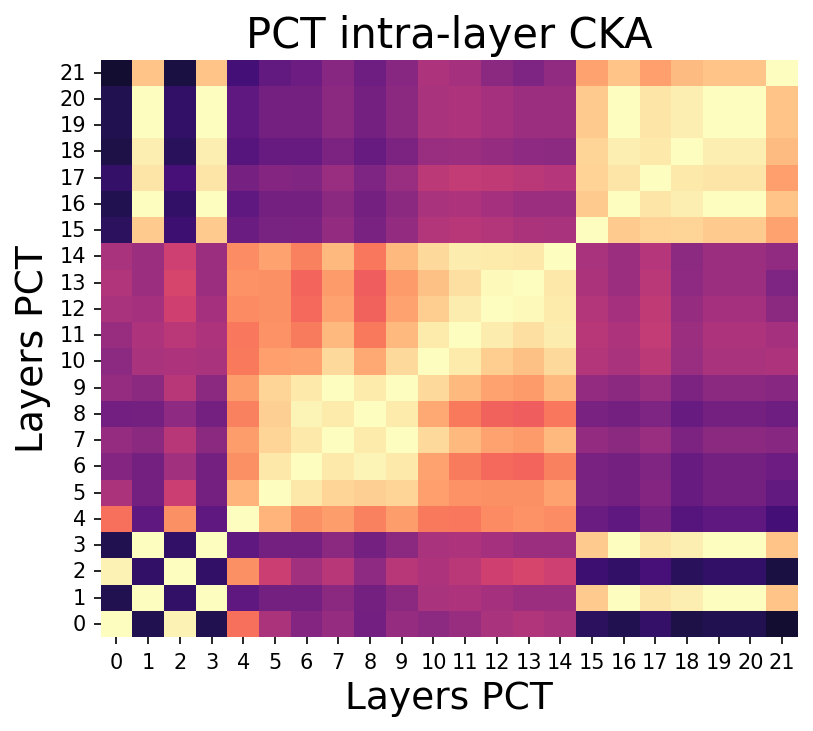

In [60]:
fig, ax = viz_cka_matrix(cka_matrix_pct,
                         tick_interval=5,
                         xylabel='Layers PCT', title='PCT intra-layer CKA')
# save graph
fig.savefig(os.path.join(output_path  , "cka", "cka_pct.svg"), bbox_inches='tight')

## Cross-model CKA

In [37]:
cka_matrix_cross = compute_cka_cross(features_papnet, features_pct, device)

Computing cross CKA for 33 x 24 layers...


Cross CKA: 100%|██████████| 792/792 [02:44<00:00,  4.82it/s]


In [38]:
np.save(os.path.join(output_path, "cka", "cka_cross.npy"), cka_matrix_cross)
np.savetxt(os.path.join(output_path, "cka", "cka_cross.csv"), cka_matrix_cross, delimiter=",")

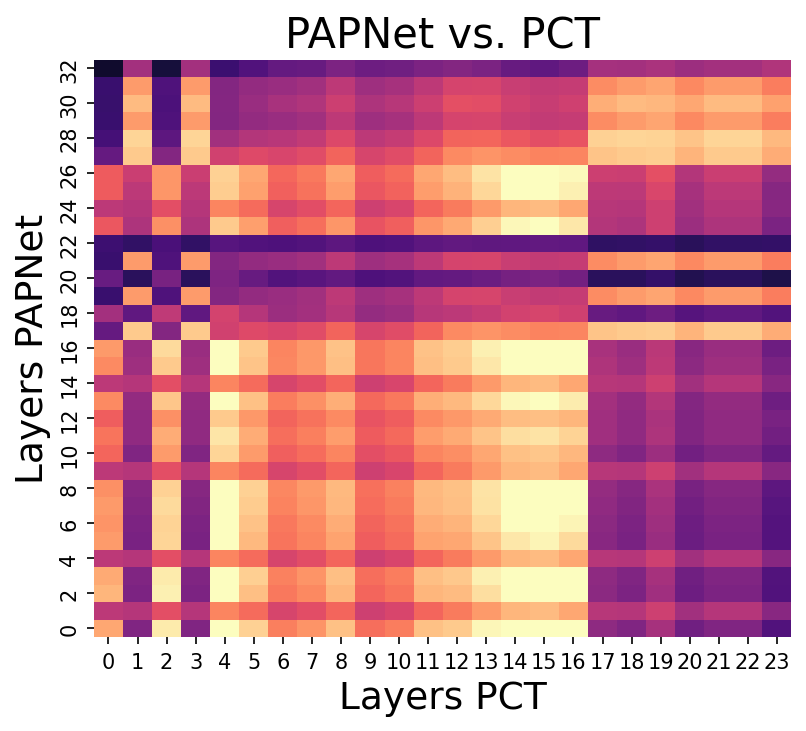

In [48]:
fig, ax = plt.subplots(figsize=(6, 5), dpi=150)
ax = sns.heatmap(cka_matrix_cross,
            cmap='magma', annot=False, ax=ax, vmin=0.0, vmax=0.7, cbar=False)
ax.set_title('PAPNet vs. PCT', fontsize=20)
ax.set_xlabel('Layers PCT', fontsize=18)
ax.set_ylabel('Layers PAPNet', fontsize=18)
ax.invert_yaxis()  # So that first layer is at the bottom
fig.savefig(os.path.join(output_path, "cka", "cka_cross.svg"), bbox_inches='tight')